# Lamé Hollow Sphere — DeepONet3D Training

Trains a **DeepONet3D** to learn the operator

$$G : (p_i,\, p_e,\, E,\, \nu) \;\longmapsto\; \sigma_{\text{vm}}(x,y,z) \in \mathbb{R}^{16000}$$

for a thick-walled hollow sphere under combined internal and external pressure (Lamé, 1852).

| Component | Description |
|---|---|
| **Branch net** | MLP(4 → 256 → 256 → 256 → 128) — encodes the 4 physics parameters |
| **Trunk net**  | MLP(3 → 256 → 256 → 256 → 128) + tanh — encodes the 3-D query coordinate |
| **Output**     | `einsum('bp,np→bn')` + bias — von Mises stress at each query point |

See [`docs/lame_sphere_problem.md`](../docs/lame_sphere_problem.md) for the full problem description and analytical solution.

---
### Mesh — volumetric VTK (done)

`sphere-FEMMeshGmsh.vtk` is a **volumetric** unstructured mesh with 409 230 nodes loaded by
`_load_vtk_vertices` in `src/neural_operators/data/lame_sphere.py`:

| Region | Points | Share |
|---|---|---|
| Inner surface (r < 0.205 m) | 6 926 | 1.7 % |
| Shell interior | 359 686 | 87.9 % |
| Outer surface (r > 0.495 m) | 42 618 | 10.4 % |

**⚠️ TODO — Imbalance still applies:**
The outer surface still holds ~6× more nodes than the inner surface.
The inner wall carries the maximum stress and is the most safety-critical region.
Regenerate the dataset (`python scripts/generate_lame_sphere_dataset.py`) then apply the weighted loss in the **Training** section below.

---

In [1]:
from __future__ import annotations

import copy
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import torch
import torch.nn as nn
import yaml
from torch.utils.data import DataLoader, TensorDataset

REPO_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from neural_operators.models import DeepONet3D
from neural_operators.data.lame_sphere import (
    A, B, N_PTS, QUERY_XYZ,
    PI_RANGE, PE_RANGE, E_RANGE, NU_RANGE,
    load_sphere_mesh,
)
from neural_operators.utils.metrics import metrics_summary

# Derived geometry constants (used in analytical formula)
_A3    = A ** 3
_B3    = B ** 3
_DENOM = _B3 - _A3

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_CUDA = device.type == "cuda"
DATA_DIR = REPO_ROOT / "dataset"
OUT_DIR  = REPO_ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print(f"Device  : {device}")
print(f"N_PTS   : {N_PTS}  (FEM mesh vertices from sphere-FEMMeshGmsh.vtk)")
print(f"Geometry: a={A} m, b={B} m")

Device  : cuda
N_PTS   : 409230  (FEM mesh vertices from sphere-FEMMeshGmsh.vtk)
Geometry: a=0.2 m, b=0.5 m


## Load configuration

In [2]:
with open(REPO_ROOT / "configs" / "lame_sphere.yaml") as f:
    cfg = yaml.safe_load(f)

norm     = cfg["normalisation"]
don_cfg  = cfg["deeponet"]
tr_cfg   = cfg["training"]
lap_cfg  = cfg.get("laptop", {})

EPOCHS     = tr_cfg["epochs"]
LR         = tr_cfg["lr"]
DON_BATCH  = tr_cfg["don_batch"]
EVAL_BATCH = tr_cfg["eval_batch"]
VAL_EVERY  = tr_cfg["val_every"]

# Laptop / resource limits — set to None to use the full dataset
N_TRAIN     = lap_cfg.get("n_train",     None)
N_VAL       = lap_cfg.get("n_val",       None)
N_TEST      = lap_cfg.get("n_test",      None)
N_QUERY_PTS = lap_cfg.get("n_query_pts", None)  # fixed mesh-point subset size
N_BATCH_PTS = lap_cfg.get("n_batch_pts", None)  # per-batch random subsampling size
LAP_SEED    = lap_cfg.get("seed", 0)

print(f"Epochs={EPOCHS}, batch={DON_BATCH}, lr={LR}")
if N_TRAIN is not None:
    print(
        f"[Laptop] train={N_TRAIN} cases, val={N_VAL}, test={N_TEST}  |  "
        f"query_pts={N_QUERY_PTS}, batch_pts={N_BATCH_PTS}"
    )

Epochs=100, batch=32, lr=0.001


### ⚠️ TODO — Normalisation

**`sigma_vm_scale` is too large for low-Δp cases.**
`sigma_vm_scale = 100 MPa` equals the maximum possible stress in the dataset.
Cases where `p_i − p_e` is small (≈ 0.1–0.2 MPa) produce σ_vm in the 0.1–1 MPa range,
which after dividing by 100 MPa gives normalised targets < 0.01 — essentially zero in the MSE.
The model never learns these cases, causing rel-L2 errors of 40–50× on the worst outliers.

Options (pick one):
- Set `sigma_vm_scale` in `configs/lame_sphere.yaml` to the training-set **mean** σ_vm instead of the max (~10–15 MPa). Rerun training.
- Switch to a **relative loss** in the training cell below: `loss = ((pred - target) / (target.abs() + eps)).pow(2).mean()`.
- Both.

## Load and normalise data

In [3]:
import pandas as pd

# Fixed random subset of mesh points — built before loading so the loader can subsample inline.
_rng = np.random.default_rng(LAP_SEED)
QUERY_IDX = (
    np.sort(_rng.choice(N_PTS, N_QUERY_PTS, replace=False))
    if (N_QUERY_PTS is not None and N_QUERY_PTS < N_PTS)
    else np.arange(N_PTS)
)
N_ACTIVE_PTS  = len(QUERY_IDX)
QUERY_XYZ_ACT = QUERY_XYZ[QUERY_IDX]   # (N_ACTIVE_PTS, 3) — active query coordinates
print(f"Mesh points: {N_ACTIVE_PTS:,} / {N_PTS:,}")

_LOAD_COLS = ["case_id", "p_i", "p_e", "E", "nu", "sigma_vm"]   # skip u_r, sigma_r, sigma_theta


def load_split_streaming(name: str, query_idx: np.ndarray, n_cases: int | None = None):
    """Stream parquet, subsample sigma_vm on-the-fly per batch.

    Reads only the 2 needed column groups (scalars + sigma_vm), skipping u_r / sigma_r /
    sigma_theta.  This cuts disk reads by ~75 % and is the dominant cost here.

    Peak RAM = one decompressed batch (~210 MB), freed each iteration.
    Accumulated output = n_cases × len(query_idx) × 4 B  (~57 MB for 3500 cases).
    Returns (params_df, sigma_vm_array_Pa).
    """
    path = DATA_DIR / f"lame_sphere_{name}.parquet"
    pf   = pq.ParquetFile(path)
    n_q  = len(query_idx)
    param_cols = ["case_id", "p_i", "p_e", "E", "nu"]

    param_chunks: list[pd.DataFrame] = []
    sigma_chunks: list[np.ndarray]   = []
    n_read = 0

    for batch in pf.iter_batches(batch_size=128, columns=_LOAD_COLS):
        need = (n_cases - n_read) if n_cases is not None else len(batch)
        if need <= 0:
            break
        if len(batch) > need:
            batch = batch.slice(0, need)

        param_chunks.append(batch.select(param_cols).to_pandas())

        # Subsample sigma_vm immediately — never hold the full 409 K-point array
        vm_col = batch.column("sigma_vm")
        chunk  = np.empty((len(batch), n_q), dtype=np.float32)
        for i, arr in enumerate(vm_col):
            chunk[i] = np.asarray(arr, dtype=np.float32)[query_idx]
        sigma_chunks.append(chunk)

        n_read += len(batch)

    params_df = pd.concat(param_chunks, ignore_index=True)
    sigma_vm  = np.concatenate(sigma_chunks, axis=0)   # (n_cases, n_q) float32, Pa
    return params_df, sigma_vm


train_df, train_vm_raw = load_split_streaming("train", QUERY_IDX, N_TRAIN)
val_df,   val_vm_raw   = load_split_streaming("val",   QUERY_IDX, N_VAL)
test_df,  test_vm_raw  = load_split_streaming("test",  QUERY_IDX, N_TEST)

print(f"Rows — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")


def normalise_params(df) -> np.ndarray:
    """Map 4 physics params to [0, 1] each.  Returns (N, 4) float32."""
    p_i_n = (df["p_i"].values - norm["pi_min"]) / (norm["pi_max"] - norm["pi_min"])
    p_e_n =  df["p_e"].values / norm["pe_max"]
    E_n   = (np.log(df["E"].values.astype(np.float64)) - norm["E_log_min"]) / (
                norm["E_log_max"] - norm["E_log_min"]
            )
    nu_n  = (df["nu"].values - norm["nu_min"]) / (norm["nu_max"] - norm["nu_min"])
    return np.stack([p_i_n, p_e_n, E_n, nu_n], axis=1).astype(np.float32)


don_p_tr = normalise_params(train_df)
don_u_tr = train_vm_raw / norm["sigma_vm_scale"]   # normalised

don_p_va = normalise_params(val_df)
don_u_va = val_vm_raw / norm["sigma_vm_scale"]

don_p_te = normalise_params(test_df)
don_u_te = test_vm_raw / norm["sigma_vm_scale"]

print(f"Branch input shape : {don_p_tr.shape}")
print(f"Target field shape : {don_u_tr.shape}")
print(f"sigma_vm range (train, normalised): [{don_u_tr.min():.4f}, {don_u_tr.max():.4f}]")

Mesh points: 4,096 / 409,230
Rows — train: 3500, val: 750, test: 750
Branch input shape : (3500, 4)
Target field shape : (3500, 4096)
sigma_vm range (train, normalised): [0.0001, 0.3184]


## DataLoaders

In [4]:
# Trunk query: radial distance r = ‖xyz‖, normalised to [0, 1] over [A, B].
# σ_vm depends only on r, not on direction — passing r instead of (x,y,z) lets
# the trunk learn the 1-D function 1/r³ directly rather than discovering
# rotational invariance from data.
_r_raw = np.linalg.norm(QUERY_XYZ_ACT, axis=1, keepdims=True).astype(np.float32)
TRUNK_R = torch.from_numpy((_r_raw - A) / (B - A)).to(device)   # (N_ACTIVE_PTS, 1), in [0, 1]

don_train_loader = DataLoader(
    TensorDataset(torch.from_numpy(don_p_tr), torch.from_numpy(don_u_tr)),
    batch_size=DON_BATCH,
    shuffle=True,
    pin_memory=IS_CUDA,
    num_workers=0,
)

print(f"Train batches per epoch: {len(don_train_loader)}")
print(f"Trunk input : r  normalised to [{TRUNK_R.min():.3f}, {TRUNK_R.max():.3f}]")


Train batches per epoch: 110
Trunk input : r  normalised to [-0.000, 1.000]


## Model

### ⚠️ TODOs — Loss function & schedule

**1. Rebalance inner vs outer surface.**
The current `nn.MSELoss()` (unweighted mean) treats all 12 418 points equally.
With 86 % of points on the outer surface, the inner wall — where σ_vm peaks — gets 6× less gradient signal.
Replace with a weighted loss:

```python
# Build once after QUERY_XYZ is loaded
r_pts   = torch.from_numpy(np.linalg.norm(QUERY_XYZ, axis=1)).to(device)  # (N_PTS,)
w       = torch.where(r_pts < 0.25, 6.0, 1.0)   # upweight inner surface
w       = w / w.mean()                            # keep loss scale stable

def weighted_mse(pred, target):
    return ((pred - target) ** 2 * w).mean()

loss_fn = weighted_mse
```

**2. Use a relative loss to fix outliers on low-Δp cases.**
```python
EPS = 1e-4   # in normalised units (~10 kPa physical)
def relative_loss(pred, target):
    return ((pred - target) / (target.abs() + EPS)).pow(2).mean()

loss_fn = relative_loss
```

**3. Train longer — the val curve had not plateaued at epoch 200.**
Increase `epochs` in `configs/lame_sphere.yaml` to 400 (or use early stopping on val loss).

In [5]:
don_model = DeepONet3D(
    param_dim    = don_cfg["param_dim"],
    p            = don_cfg["p"],
    width        = don_cfg["width"],
    depth        = don_cfg["depth"],
    trunk_in_dim = don_cfg.get("trunk_in_dim", 3),
).to(device)

n_params = sum(p.numel() for p in don_model.parameters() if p.requires_grad)
print(f"DeepONet3D trainable parameters: {n_params:,}")
print(f"Trunk input dim: {don_cfg.get('trunk_in_dim', 3)}")


DeepONet3D trainable parameters: 330,753
Trunk input dim: 1


## Training

In [6]:
optimizer = torch.optim.Adam(
    don_model.parameters(), lr=LR, weight_decay=tr_cfg["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Relative loss — EPS=1e-2 (normalised ≈ 1 MPa physical) prevents gradient
# explosions when near-zero targets appear in small-Δp cases.
_REL_EPS = 1e-2

def rel_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return ((pred - target) / (target.abs() + _REL_EPS)).pow(2).mean()

mse_fn = nn.MSELoss()   # for val monitoring only
_use_batch_pts = N_BATCH_PTS is not None and N_BATCH_PTS < N_ACTIVE_PTS


def eval_mse(model, P: np.ndarray, U: np.ndarray) -> float:
    model.eval()
    total = 0.0
    P_t, U_t = torch.from_numpy(P), torch.from_numpy(U)
    with torch.no_grad():
        for i in range(0, len(P), EVAL_BATCH):
            pb = P_t[i : i + EVAL_BATCH].to(device)
            ub = U_t[i : i + EVAL_BATCH].to(device)
            total += mse_fn(model(pb, TRUNK_R), ub).item() * len(pb)
    return total / len(P)


train_hist, val_hist = [], []
best_val, best_state = float("inf"), None
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    don_model.train()
    ep_loss = 0.0
    for params_b, u_b in don_train_loader:
        params_b = params_b.to(device, non_blocking=IS_CUDA)
        u_b      = u_b.to(device, non_blocking=IS_CUDA)

        if _use_batch_pts:
            pts_idx = torch.randperm(N_ACTIVE_PTS, device=device)[:N_BATCH_PTS]
            trunk_b = TRUNK_R[pts_idx]
            u_b     = u_b[:, pts_idx]
        else:
            trunk_b = TRUNK_R

        optimizer.zero_grad(set_to_none=True)
        loss = rel_loss(don_model(params_b, trunk_b), u_b)
        loss.backward()
        nn.utils.clip_grad_norm_(don_model.parameters(), max_norm=1.0)
        optimizer.step()
        ep_loss += loss.item() * len(params_b)
    ep_loss /= len(don_p_tr)
    train_hist.append(ep_loss)
    scheduler.step()

    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = eval_mse(don_model, don_p_va, don_u_va)
        val_hist.append((epoch, val_loss))
        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(don_model.state_dict())
        lr_now = scheduler.get_last_lr()[0]
        print(
            f"[{epoch:>3}/{EPOCHS}]  train_rel={ep_loss:.4e}  val_mse={val_loss:.4e}"
            f"  lr={lr_now:.2e}  best_val={best_val:.4e}"
        )

don_model.load_state_dict(best_state)
torch.save(
    {"state_dict": best_state, "val_loss": best_val, "cfg": cfg},
    OUT_DIR / "don_lame_sphere.pt",
)
print(f"\nTraining done in {time.time()-t0:.1f}s  |  best val MSE = {best_val:.4e}")


[  1/100]  train_rel=1.8666e+02  val_mse=2.0464e-03  lr=1.00e-03  best_val=2.0464e-03
[ 10/100]  train_rel=3.8926e-02  val_mse=1.3610e-04  lr=9.76e-04  best_val=1.3610e-04
[ 20/100]  train_rel=4.4132e-03  val_mse=1.1017e-05  lr=9.05e-04  best_val=1.1017e-05
[ 30/100]  train_rel=2.3986e-03  val_mse=1.1114e-05  lr=7.94e-04  best_val=1.1017e-05
[ 40/100]  train_rel=1.4041e-03  val_mse=6.8063e-06  lr=6.55e-04  best_val=6.8063e-06
[ 50/100]  train_rel=1.3510e-03  val_mse=4.1947e-06  lr=5.00e-04  best_val=4.1947e-06
[ 60/100]  train_rel=3.1920e-04  val_mse=1.7129e-06  lr=3.45e-04  best_val=1.7129e-06
[ 70/100]  train_rel=1.3775e-04  val_mse=1.2925e-06  lr=2.06e-04  best_val=1.2925e-06
[ 80/100]  train_rel=9.7802e-05  val_mse=1.0512e-06  lr=9.55e-05  best_val=1.0512e-06
[ 90/100]  train_rel=6.3833e-05  val_mse=8.2842e-07  lr=2.45e-05  best_val=8.2842e-07
[100/100]  train_rel=5.8289e-05  val_mse=8.3014e-07  lr=0.00e+00  best_val=8.2842e-07

Training done in 40.0s  |  best val MSE = 8.2842e-07


## Training curves

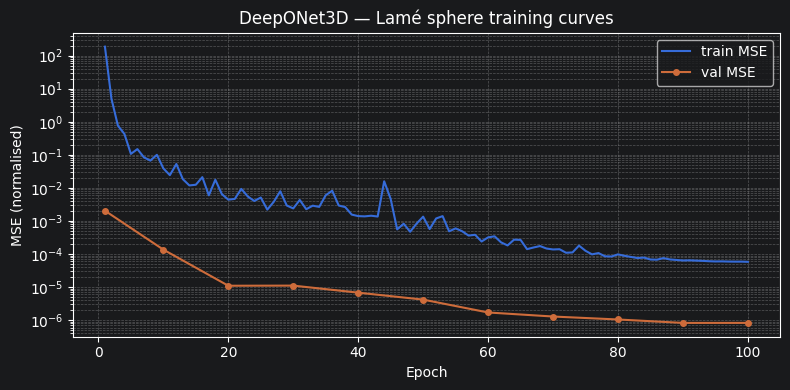

In [7]:
val_epochs, val_losses = zip(*val_hist)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, EPOCHS + 1), train_hist, lw=1.5, label="train MSE")
ax.semilogy(val_epochs, val_losses, "o-", ms=4, lw=1.5, label="val MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (normalised)")
ax.set_title("DeepONet3D — Lamé sphere training curves")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_training_curves.png", dpi=120)
plt.show()

## Test-set evaluation

In [8]:
don_model.eval()
all_preds = []
P_t = torch.from_numpy(don_p_te)
with torch.no_grad():
    for i in range(0, len(don_p_te), EVAL_BATCH):
        pb = P_t[i : i + EVAL_BATCH].to(device)
        all_preds.append(don_model(pb, TRUNK_R).cpu().numpy())

pred_norm = np.concatenate(all_preds, axis=0)   # (n_test, N_ACTIVE_PTS), normalised
pred_vm   = pred_norm * norm["sigma_vm_scale"]   # Pa
true_vm   = test_vm_raw                          # (n_test, N_ACTIVE_PTS), Pa

_mse, rel_l2_mean, rel_l2_std, max_err, rel_l2_all = metrics_summary(pred_vm, true_vm)

print(f"Test MSE         : {_mse:.4e} Pa²")
print(f"Rel L2 (mean)    : {rel_l2_mean:.4f}")
print(f"Rel L2 (std)     : {rel_l2_std:.4f}")
print(f"Max abs error    : {max_err/1e6:.4f} MPa")


Test MSE         : 8.0019e+09 Pa²
Rel L2 (mean)    : 0.0260
Rel L2 (std)     : 0.0336
Max abs error    : 1.8955 MPa


## Radial profile plots

For each selected test case: compare the DeepONet3D prediction against the analytical
ground-truth σ_vm(r) curve.  Since σ_vm depends only on r, the predicted values at a
given radial shell are averaged over all (θ, φ) directions — any residual spread
indicates the model's angular non-uniformity (ideally zero).

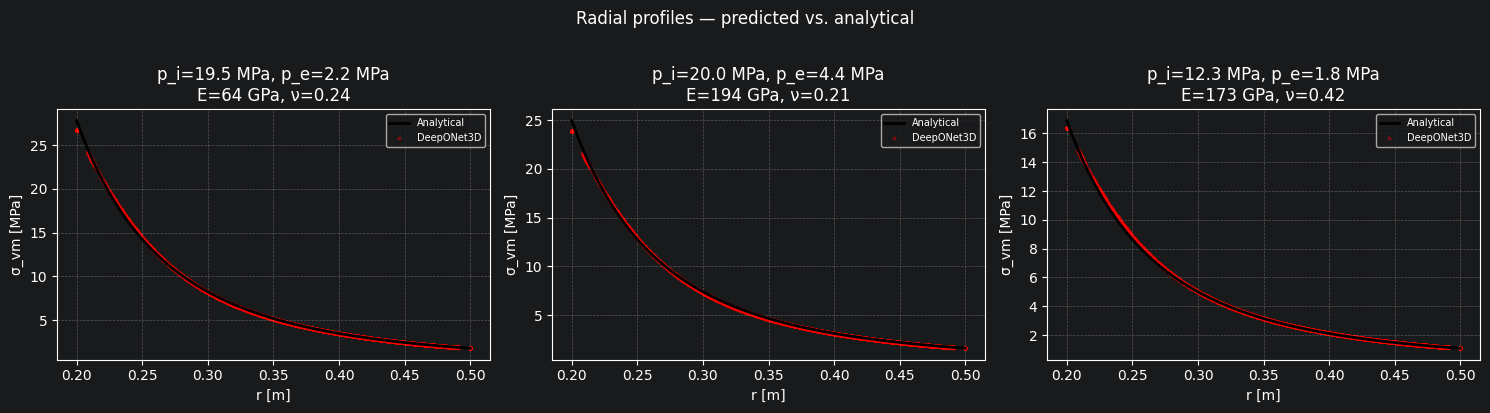

In [9]:
r_pts    = np.linalg.norm(QUERY_XYZ_ACT, axis=1)   # (N_ACTIVE_PTS,)
sort_idx = np.argsort(r_pts)
r_sorted = r_pts[sort_idx]

N_VIS   = 3
vis_ids = [0, len(test_df) // 2, len(test_df) - 1]

fig, axes = plt.subplots(1, N_VIS, figsize=(15, 4), sharey=False)

for ax, idx in zip(axes, vis_ids):
    row = test_df.iloc[idx]

    r_dense = np.linspace(A, B, 300)
    C2_case = (row.p_i - row.p_e) * _A3 * _B3 / _DENOM
    vm_analytical = np.abs(C2_case) * 3.0 / (2.0 * r_dense ** 3)

    vm_pred_sorted = pred_vm[idx][sort_idx]

    ax.plot(r_dense, vm_analytical / 1e6, "k-", lw=2, label="Analytical")
    ax.scatter(r_sorted, vm_pred_sorted / 1e6, c="red", s=4, alpha=0.3, label="DeepONet3D")
    ax.set_xlabel("r [m]")
    ax.set_ylabel("σ_vm [MPa]")
    ax.set_title(
        f"p_i={row.p_i/1e6:.1f} MPa, p_e={row.p_e/1e6:.1f} MPa\n"
        f"E={row.E/1e9:.0f} GPa, ν={row.nu:.2f}"
    )
    ax.legend(fontsize=7)
    ax.grid(True, ls="--", alpha=0.4)

plt.suptitle("Radial profiles — predicted vs. analytical", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_radial_profiles.png", dpi=120, bbox_inches="tight")
plt.show()

## Equatorial cross-section

Slice at θ = π/2 (equatorial plane z = 0).  The predicted σ_vm should show
perfect circular (radially symmetric) contours.

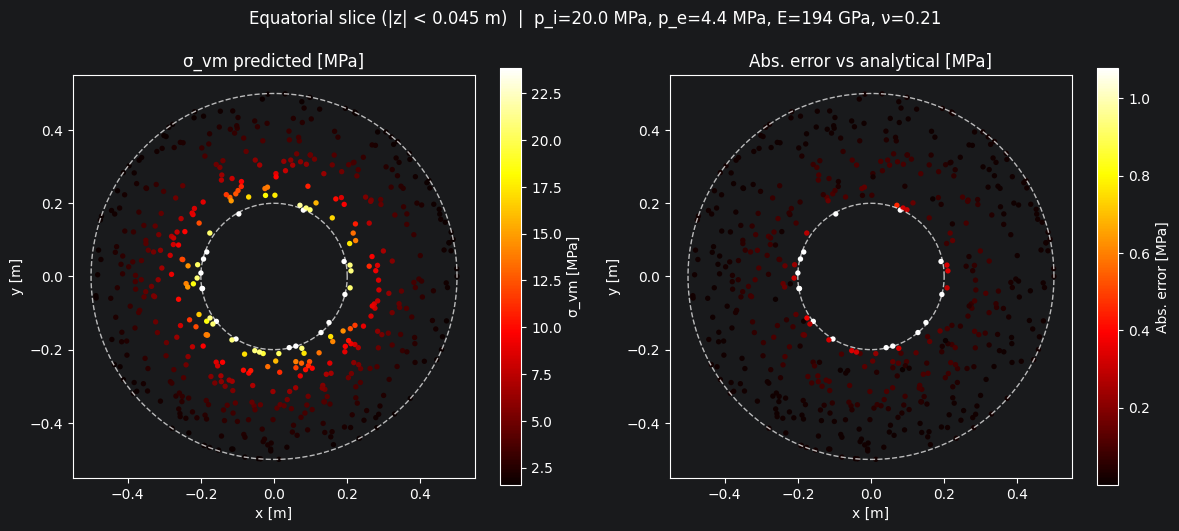

In [10]:
case_idx = vis_ids[1]
row = test_df.iloc[case_idx]

z_tol   = (B - A) * 0.15
eq_mask = np.abs(QUERY_XYZ_ACT[:, 2]) < z_tol
eq_x    = QUERY_XYZ_ACT[eq_mask, 0]
eq_y    = QUERY_XYZ_ACT[eq_mask, 1]

eq_vm_pred = pred_vm[case_idx][eq_mask]

r_full          = np.linalg.norm(QUERY_XYZ_ACT, axis=1).astype(np.float64)
C2_case         = (row.p_i - row.p_e) * _A3 * _B3 / _DENOM
vm_analytical   = np.abs(C2_case) * 3.0 / (2.0 * r_full ** 3)
abs_err_eq      = np.abs(pred_vm[case_idx][eq_mask] - vm_analytical[eq_mask].astype(np.float32))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc = axes[0].scatter(eq_x, eq_y, c=eq_vm_pred / 1e6, cmap="hot", s=15, linewidths=0)
fig.colorbar(sc, ax=axes[0], label="σ_vm [MPa]")
axes[0].set_aspect("equal")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].set_title("σ_vm predicted [MPa]")

sc2 = axes[1].scatter(eq_x, eq_y, c=abs_err_eq / 1e6, cmap="hot", s=15, linewidths=0)
fig.colorbar(sc2, ax=axes[1], label="Abs. error [MPa]")
axes[1].set_aspect("equal")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
axes[1].set_title("Abs. error vs analytical [MPa]")

for ax in axes:
    theta_c = np.linspace(0, 2 * np.pi, 200)
    ax.plot(A * np.cos(theta_c), A * np.sin(theta_c), "w--", lw=1, alpha=0.7)
    ax.plot(B * np.cos(theta_c), B * np.sin(theta_c), "w--", lw=1, alpha=0.7)

plt.suptitle(
    f"Equatorial slice (|z| < {z_tol:.3f} m)  |  "
    f"p_i={row.p_i/1e6:.1f} MPa, p_e={row.p_e/1e6:.1f} MPa, "
    f"E={row.E/1e9:.0f} GPa, ν={row.nu:.2f}",
    y=1.02,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_equatorial.png", dpi=120, bbox_inches="tight")
plt.show()

## Error distribution

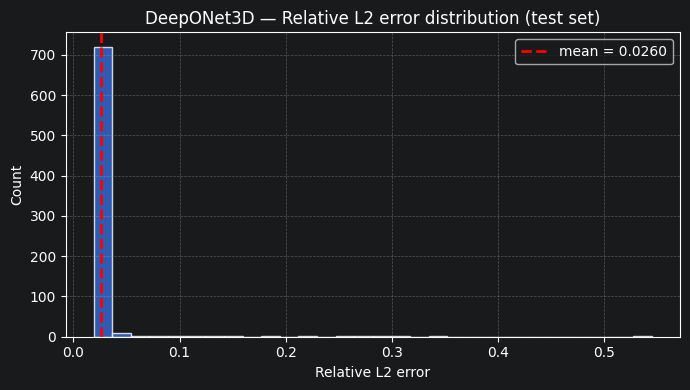

Worst 5 test cases (rel L2):
  case  683: rel_L2=0.5456  p_i=1.9 MPa  p_e=1.8 MPa  E=179 GPa  nu=0.209
  case  671: rel_L2=0.3383  p_i=4.3 MPa  p_e=4.1 MPa  E=172 GPa  nu=0.226
  case    5: rel_L2=0.3051  p_i=3.7 MPa  p_e=3.5 MPa  E=156 GPa  nu=0.445
  case  693: rel_L2=0.2978  p_i=3.0 MPa  p_e=2.9 MPa  E=164 GPa  nu=0.254
  case   23: rel_L2=0.2720  p_i=3.0 MPa  p_e=2.9 MPa  E=63 GPa  nu=0.230


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(rel_l2_all, bins=30, alpha=0.8, edgecolor="white")
ax.axvline(rel_l2_mean, color="red", ls="--", lw=2, label=f"mean = {rel_l2_mean:.4f}")
ax.set_xlabel("Relative L2 error")
ax.set_ylabel("Count")
ax.set_title("DeepONet3D — Relative L2 error distribution (test set)")
ax.legend()
ax.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR / "lame_sphere_error_hist.png", dpi=120)
plt.show()

print(f"Worst 5 test cases (rel L2):")
top5 = np.argsort(rel_l2_all)[-5:][::-1]
for i in top5:
    row = test_df.iloc[i]
    print(f"  case {i:>4}: rel_L2={rel_l2_all[i]:.4f}  "
          f"p_i={row.p_i/1e6:.1f} MPa  p_e={row.p_e/1e6:.1f} MPa  "
          f"E={row.E/1e9:.0f} GPa  nu={row.nu:.3f}")

## 3-D field visualization — PyVista

Render the predicted and ground-truth von Mises stress on the full FEM mesh.
`pv.set_jupyter_backend('static')` produces inline PNG; change to `'html'` for
an interactive 3-D widget in JupyterLab with the `trame` extra installed.

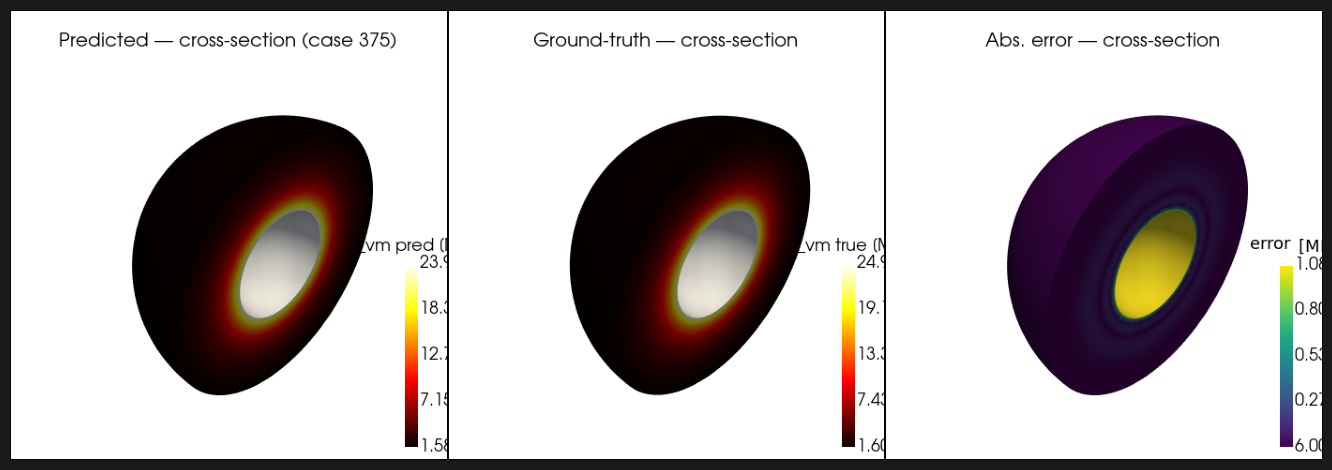

Saved → /home/hamza/Desktop/deep-operator-network/outputs/lame_sphere_3d_crosssection.png


In [15]:
import pyvista as pv

pv.set_jupyter_backend('static')

# Full-mesh trunk input — model trained on 4096 pts generalises to any r
_r_full = np.linalg.norm(QUERY_XYZ, axis=1, keepdims=True).astype(np.float32)
TRUNK_R_FULL = torch.from_numpy((_r_full - A) / (B - A)).to(device)   # (409230, 1)

# Inference for the visualisation case
case_idx = vis_ids[1]
row = test_df.iloc[case_idx]
p_b = torch.from_numpy(don_p_te[case_idx : case_idx + 1]).to(device)
don_model.eval()
with torch.no_grad():
    pred_full_vm = don_model(p_b, TRUNK_R_FULL).cpu().numpy()[0] * norm["sigma_vm_scale"]

# Analytical ground truth (same formula used to generate the parquet)
_r_all    = np.clip(np.linalg.norm(QUERY_XYZ, axis=1), A, B).astype(np.float64)
_C2       = (row.p_i - row.p_e) * A**3 * B**3 / (B**3 - A**3)
true_full_vm = (np.abs(_C2) * 3.0 / (2.0 * _r_all**3)).astype(np.float32)

sphere_mesh = load_sphere_mesh()
sphere_mesh["sigma_vm_pred_MPa"] = pred_full_vm / 1e6
sphere_mesh["sigma_vm_true_MPa"] = true_full_vm / 1e6
sphere_mesh["abs_err_MPa"]       = np.abs(pred_full_vm - true_full_vm) / 1e6

clip = sphere_mesh.clip(normal="y", origin=(0, 0, 0))

_path_3d = str(OUT_DIR / "lame_sphere_3d_crosssection.png")
pl = pv.Plotter(shape=(1, 3), off_screen=True, window_size=(1400, 480))

pl.subplot(0, 0)
pl.add_mesh(clip, scalars="sigma_vm_pred_MPa", cmap="hot",
            scalar_bar_args={"title": "σ_vm pred [MPa]", "vertical": True})
pl.add_title(f"Predicted — cross-section (case {case_idx})", font_size=9)
pl.view_isometric()

pl.subplot(0, 1)
pl.add_mesh(clip.copy(), scalars="sigma_vm_true_MPa", cmap="hot",
            scalar_bar_args={"title": "σ_vm true [MPa]", "vertical": True})
pl.add_title("Ground-truth — cross-section", font_size=9)
pl.view_isometric()

pl.subplot(0, 2)
pl.add_mesh(clip.copy(), scalars="abs_err_MPa", cmap="viridis",
            scalar_bar_args={"title": "|error| [MPa]", "vertical": True})
pl.add_title("Abs. error — cross-section", font_size=9)
pl.view_isometric()

pl.screenshot(_path_3d)
pl.close()

img = plt.imread(_path_3d)
fig, ax = plt.subplots(figsize=(14, 4.8))
ax.imshow(img)
ax.axis("off")
plt.tight_layout()
plt.savefig(_path_3d, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {_path_3d}")


/tmp/ipykernel_66278/3461307618.py:2: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface = sphere_mesh.extract_surface()


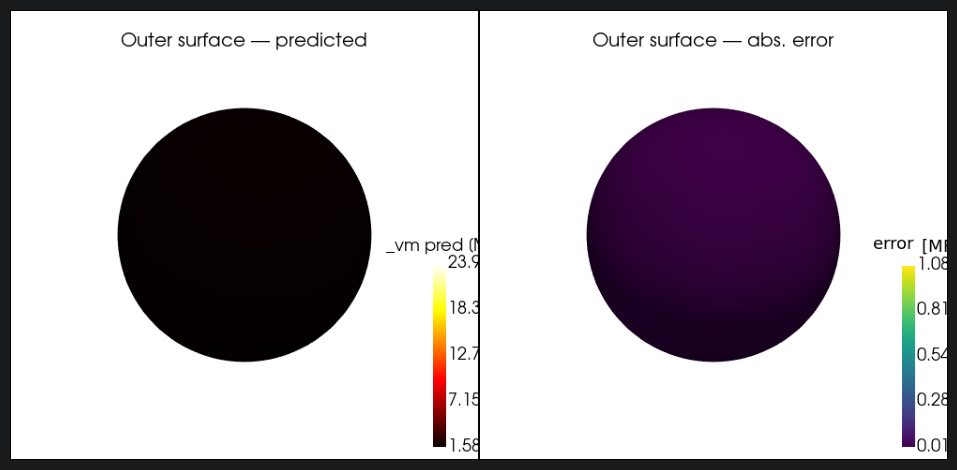

Saved → /home/hamza/Desktop/deep-operator-network/outputs/lame_sphere_3d_outer.png


In [16]:
# Outer surface with clim fixed to outer-surface range (avoids all-black render)
surface = sphere_mesh.extract_surface()
_smin = float(surface["sigma_vm_pred_MPa"].min())
_smax = float(surface["sigma_vm_pred_MPa"].max())

_path_outer = str(OUT_DIR / "lame_sphere_3d_outer.png")
pl2 = pv.Plotter(shape=(1, 2), off_screen=True, window_size=(1000, 480))

pl2.subplot(0, 0)
pl2.add_mesh(surface, scalars="sigma_vm_pred_MPa", cmap="hot",
             clim=[_smin, _smax],
             scalar_bar_args={"title": "σ_vm pred [MPa]", "vertical": True})
pl2.add_title("Outer surface — predicted", font_size=9)
pl2.view_isometric()

pl2.subplot(0, 1)
pl2.add_mesh(surface.copy(), scalars="abs_err_MPa", cmap="viridis",
             scalar_bar_args={"title": "|error| [MPa]", "vertical": True})
pl2.add_title("Outer surface — abs. error", font_size=9)
pl2.view_isometric()

pl2.screenshot(_path_outer)
pl2.close()

img2 = plt.imread(_path_outer)
fig2, ax2 = plt.subplots(figsize=(10, 4.8))
ax2.imshow(img2)
ax2.axis("off")
plt.tight_layout()
plt.savefig(_path_outer, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved → {_path_outer}")
